In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv("Banking_Credit_Risk_Dataset.csv")

In [4]:
df = data.copy()
df.head()

,Customer_ID,Age,Gender,Marital_Status,Education_Level,Employment_Type,Annual_Income,Region,Credit_Score,Existing_Loans_Count,...,Loan_ID,Loan_Purpose,Loan_Amount,Loan_Term_Months,Interest_Rate,Debt_to_Income_Ratio_%,Application_Date,Approval_Date,Loan_Status,Default_Risk_Flag
0,CUST1,58,Male,Divorced,Bachelor,Salaried,196780,East,555,0,...,LOAN1,Business Loan,1421086,24,15.20,722.17,2018-11-22,2018-11-26,Default,1
1,CUST2,47,Female,Married,Bachelor,Unemployed,197067,West,437,4,...,LOAN2,Business Loan,157705,24,5.15,80.03,2018-03-30,2018-04-09,Default,1
2,CUST3,65,Male,Married,High School,Unemployed,88261,East,622,4,...,LOAN3,Personal Loan,1113215,12,13.44,1261.28,2022-08-21,2022-08-25,Default,1
3,CUST4,63,Female,Divorced,PhD,Self-Employed,73260,West,553,4,...,LOAN4,Business Loan,1324205,84,17.27,1807.54,2018-09-16,2018-09-24,Default,1
4,CUST5,36,Female,Divorced,Bachelor,Unemployed,77524,Central,685,2,...,LOAN5,Business Loan,907030,48,11.94,1170.00,2018-02-24,2018-03-04,Default,1


In [7]:
df.shape

(12000, 22)

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer_ID             12000 non-null  str    
 1   Age                     12000 non-null  int64  
 2   Gender                  12000 non-null  str    
 3   Marital_Status          12000 non-null  str    
 4   Education_Level         12000 non-null  str    
 5   Employment_Type         12000 non-null  str    
 6   Annual_Income           12000 non-null  int64  
 7   Region                  12000 non-null  str    
 8   Credit_Score            12000 non-null  int64  
 9   Existing_Loans_Count    12000 non-null  int64  
 10  Dependents              12000 non-null  int64  
 11  Account_Balance         12000 non-null  int64  
 12  Loan_ID                 12000 non-null  str    
 13  Loan_Purpose            12000 non-null  str    
 14  Loan_Amount             12000 non-null  int64  
 

In [9]:
df.describe()

,Age,Annual_Income,Credit_Score,Existing_Loans_Count,Dependents,Account_Balance,Loan_Amount,Loan_Term_Months,Interest_Rate,Debt_to_Income_Ratio_%,Default_Risk_Flag
count,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,1.200000e+04,12000.000000,12000.000000,12000.000000,12000.000000
mean,43.066500,108750.920167,595.750250,2.504917,1.974167,250651.999917,7.820191e+05,54.312000,11.465249,1071.747008,0.996167
std,12.857081,53531.214521,172.969315,1.711009,1.418626,143664.706972,4.177996e+05,34.376055,3.743041,1157.944646,0.061798
min,21.000000,15003.000000,300.000000,0.000000,0.000000,11.000000,5.014000e+04,12.000000,5.000000,25.980000,0.000000
25%,32.000000,62158.500000,446.000000,1.000000,1.000000,126973.750000,4.240372e+05,24.000000,8.260000,388.607500,1.000000
50%,43.000000,109543.500000,594.000000,3.000000,2.000000,251723.000000,7.805835e+05,48.000000,11.385000,723.260000,1.000000
75%,54.000000,155492.500000,744.000000,4.000000,3.000000,375215.750000,1.148874e+06,84.000000,14.700000,1267.550000,1.000000
max,65.000000,200000.000000,900.000000,5.000000,4.000000,499977.000000,1.499997e+06,120.000000,18.000000,9919.700000,1.000000


#### Key Insights from Descriptive Statistics:
#### 1. Debt-to-Income Ratio shows substantial variation, with the maximum value considerably higher than the median, requiring further investigation for possible extreme values.

#### 2. Default_Risk_Flag has values between 0 and 1 and should be investigated further to understand the distribution of default and non-default cases.

In [10]:
df["Default_Risk_Flag"].value_counts()

Default_Risk_Flag
1    11954
0       46
Name: count, dtype: int64

#### Default Risk Flag Distribution:

#### 1. The dataset contains 11,954 records with Default_Risk_Flag = 1 and only 46 records with Default_Risk_Flag = 0.

#### 2. This represents an extremely imbalanced target variable: approximately 99.62% are class 1 and 0.38% are class 0.

In [12]:
df.isna().sum()

Customer_ID               0
Age                       0
Gender                    0
Marital_Status            0
Education_Level           0
Employment_Type           0
Annual_Income             0
Region                    0
Credit_Score              0
Existing_Loans_Count      0
Dependents                0
Account_Balance           0
Loan_ID                   0
Loan_Purpose              0
Loan_Amount               0
Loan_Term_Months          0
Interest_Rate             0
Debt_to_Income_Ratio_%    0
Application_Date          0
Approval_Date             0
Loan_Status               0
Default_Risk_Flag         0
dtype: int64

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    print("\n", col)
    print(df[col].value_counts())


 Customer_ID
Customer_ID
CUST1        1
CUST2        1
CUST3        1
CUST4        1
CUST5        1
            ..
CUST11996    1
CUST11997    1
CUST11998    1
CUST11999    1
CUST12000    1
Name: count, Length: 12000, dtype: int64

 Gender
Gender
Male      6029
Female    5971
Name: count, dtype: int64

 Marital_Status
Marital_Status
Divorced    4031
Married     4000
Single      3969
Name: count, dtype: int64

 Education_Level
Education_Level
PhD            3025
Bachelor       3012
High School    2987
Master         2976
Name: count, dtype: int64

 Employment_Type
Employment_Type
Business         3038
Self-Employed    3026
Salaried         2975
Unemployed       2961
Name: count, dtype: int64

 Region
Region
East       2481
Central    2389
West       2385
North      2379
South      2366
Name: count, dtype: int64

 Loan_ID
Loan_ID
LOAN1        1
LOAN2        1
LOAN3        1
LOAN4        1
LOAN5        1
            ..
LOAN11996    1
LOAN11997    1
LOAN11998    1
LOAN11999    1
LOAN12000

C:\Users\devip\AppData\Local\Temp\ipykernel_9564\1480324926.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


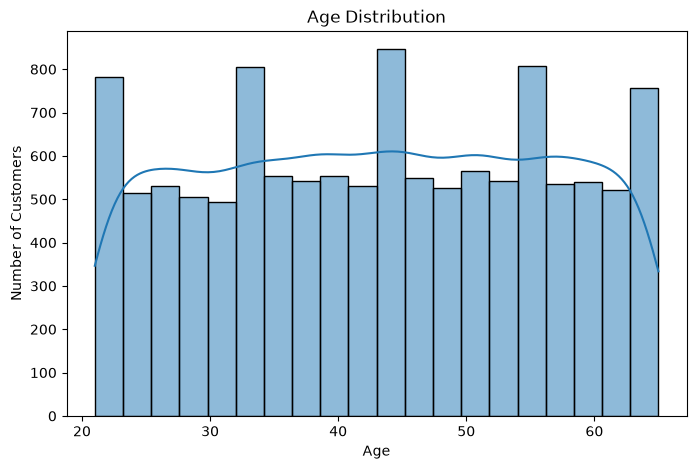

In [20]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Age"], bins=20, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

#### Age Distribution Insight:

#### The customers' ages range from 21 to 65 years.
#### The distribution is relatively even across the age range, with no major concentration or extreme values observed.

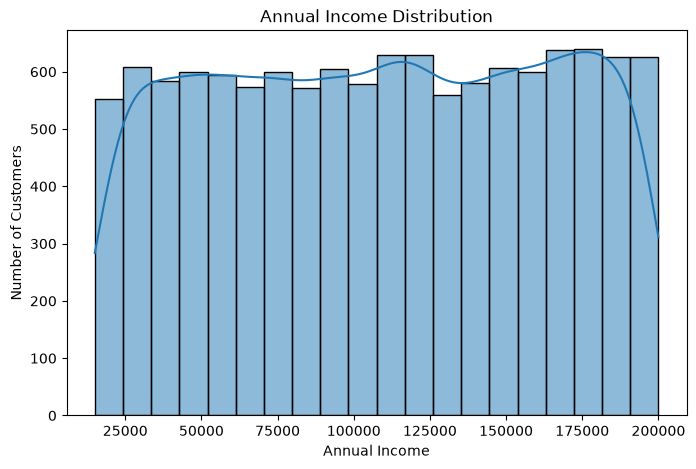

In [21]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Annual_Income"], bins=20, kde=True)

plt.title("Annual Income Distribution")
plt.xlabel("Annual Income")
plt.ylabel("Number of Customers")

plt.show()

#### Annual Income Distribution Insight:

#### Annual income ranges from approximately 15,000 to 200,000.
#### The distribution is relatively uniform, with customers spread fairly evenly across the income range.
#### No major concentration or extreme values are visually apparent.

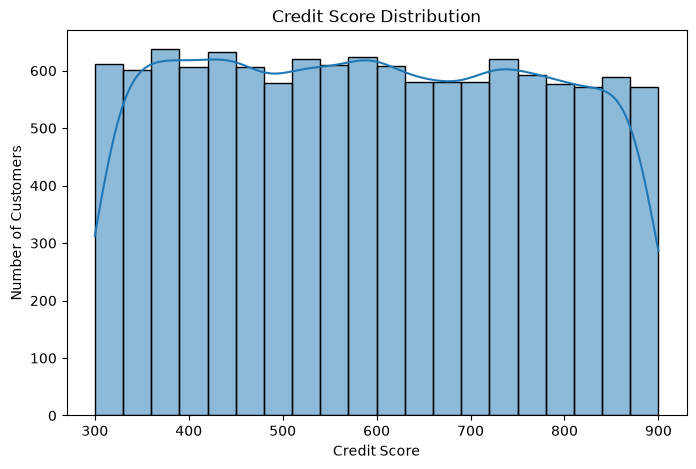

In [22]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Credit_Score"], bins=20, kde=True)

plt.title("Credit Score Distribution")
plt.xlabel("Credit Score")
plt.ylabel("Number of Customers")

plt.show()

#### Credit Score Distribution Insight:

#### Credit scores range from 300 to 900.
#### The distribution is relatively uniform, with customers spread fairly evenly across the credit-score range.
#### No strong skewness or obvious extreme values are observed.

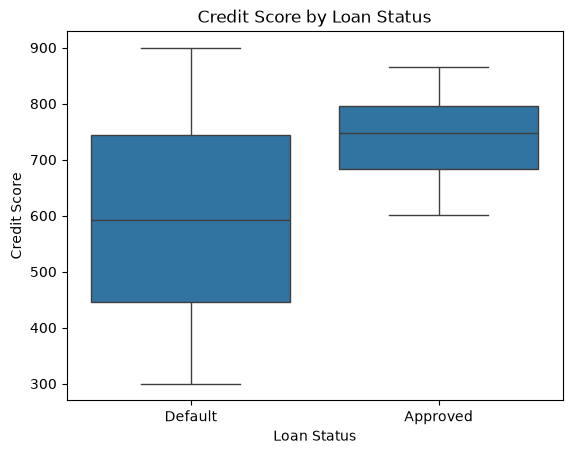

In [23]:
sns.boxplot(x="Loan_Status", y="Credit_Score", data=df)

plt.title("Credit Score by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Credit Score")

plt.show()

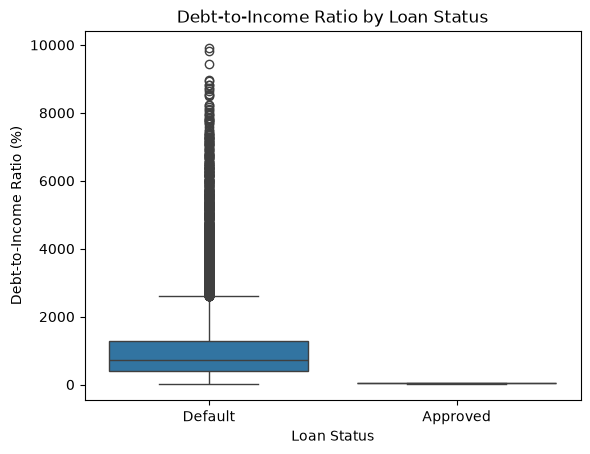

In [24]:
sns.boxplot(x="Loan_Status", y="Debt_to_Income_Ratio_%", data=df)

plt.title("Debt-to-Income Ratio by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Debt-to-Income Ratio (%)")

plt.show()

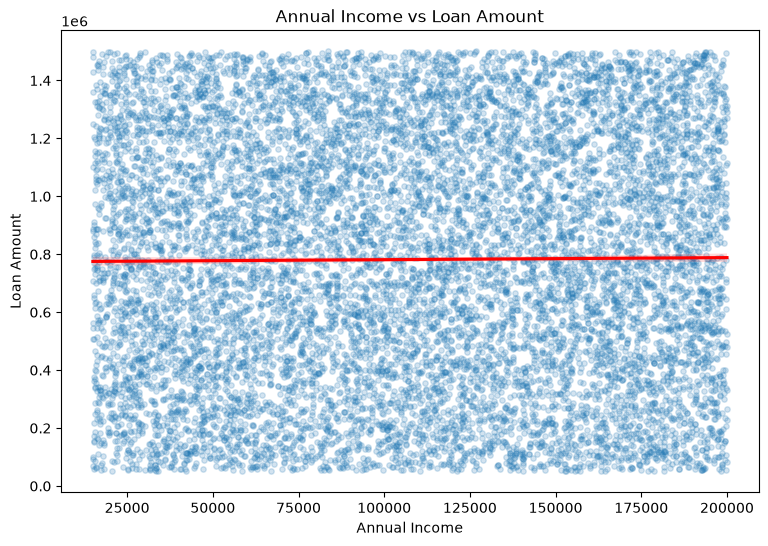

In [26]:
plt.figure(figsize=(9, 6))

sns.regplot(
    x="Annual_Income",
    y="Loan_Amount",
    data=df,
    scatter_kws={"alpha": 0.2, "s": 15},
    line_kws={"color": "red"}
)

plt.title("Annual Income vs Loan Amount")
plt.xlabel("Annual Income")
plt.ylabel("Loan Amount")

plt.show()

In [27]:
df["Annual_Income"].corr(df["Loan_Amount"])

np.float64(0.009096687971750856)

#### Annual Income vs Loan Amount:

#### The correlation coefficient between Annual Income and Loan Amount is approximately 0.009, indicating virtually no linear relationship between the two variables in this dataset.

#### The scatter plot confirms this, as the observations are widely dispersed and the regression line is almost flat.

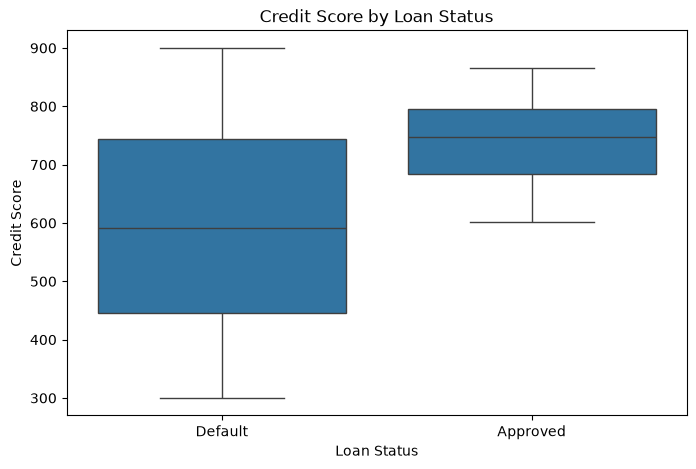

In [28]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Loan_Status",
    y="Credit_Score",
    data=df
)

plt.title("Credit Score by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Credit Score")

plt.show()

#### Credit Score vs Loan Status:

#### The approved group has a noticeably higher median credit score than the default group.

#### This suggests that credit score may be an important factor associated with loan status in this dataset.

#### However, the Loan_Status variable is highly imbalanced (11,954 Default vs 46 Approved), so this relationship should be interpreted with caution.

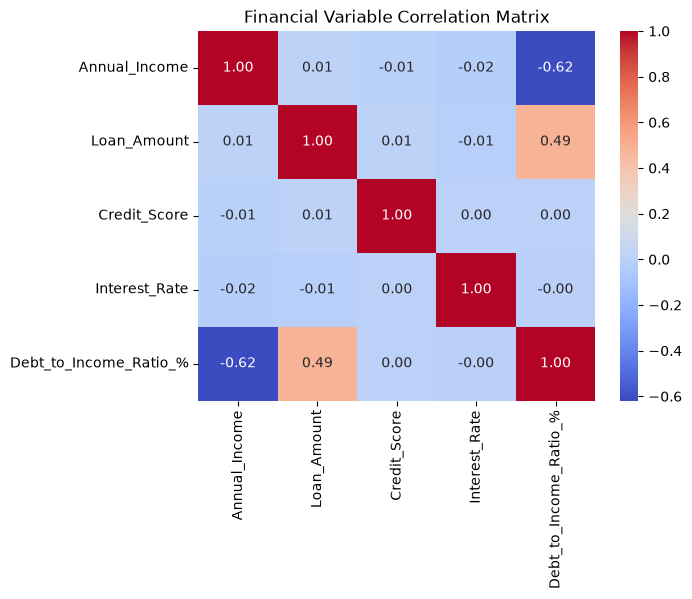

In [40]:
corr = df[
    [
        "Annual_Income",
        "Loan_Amount",
        "Credit_Score",
        "Interest_Rate",
        "Debt_to_Income_Ratio_%"
    ]
].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Financial Variable Correlation Matrix")
plt.show()

#### Financial Variable Correlation Matrix Insights:

#### 1. Annual Income and Debt-to-Income Ratio have a moderately strong negative correlation of -0.61.

#### 2. Loan Amount and Debt-to-Income Ratio have a moderate positive correlation of 0.48.

#### 3. Annual Income and Loan Amount have a very weak positive correlation of 0.02, indicating almost no linear relationship.

#### 4. Credit Score shows very weak correlation with the other financial variables.

#### 5. Interest Rate also shows very weak correlation with the other financial variables.

#### Overall:
#### The strongest relationships in the matrix involve the Debt-to-Income Ratio, particularly with Annual Income and Loan Amount. Most other financial variables have little linear correlation with each other.

In [32]:
risk_columns = [
    "Credit_Score",
    "Annual_Income",
    "Loan_Amount",
    "Interest_Rate",
    "Debt_to_Income_Ratio_%",
    "Existing_Loans_Count"
]

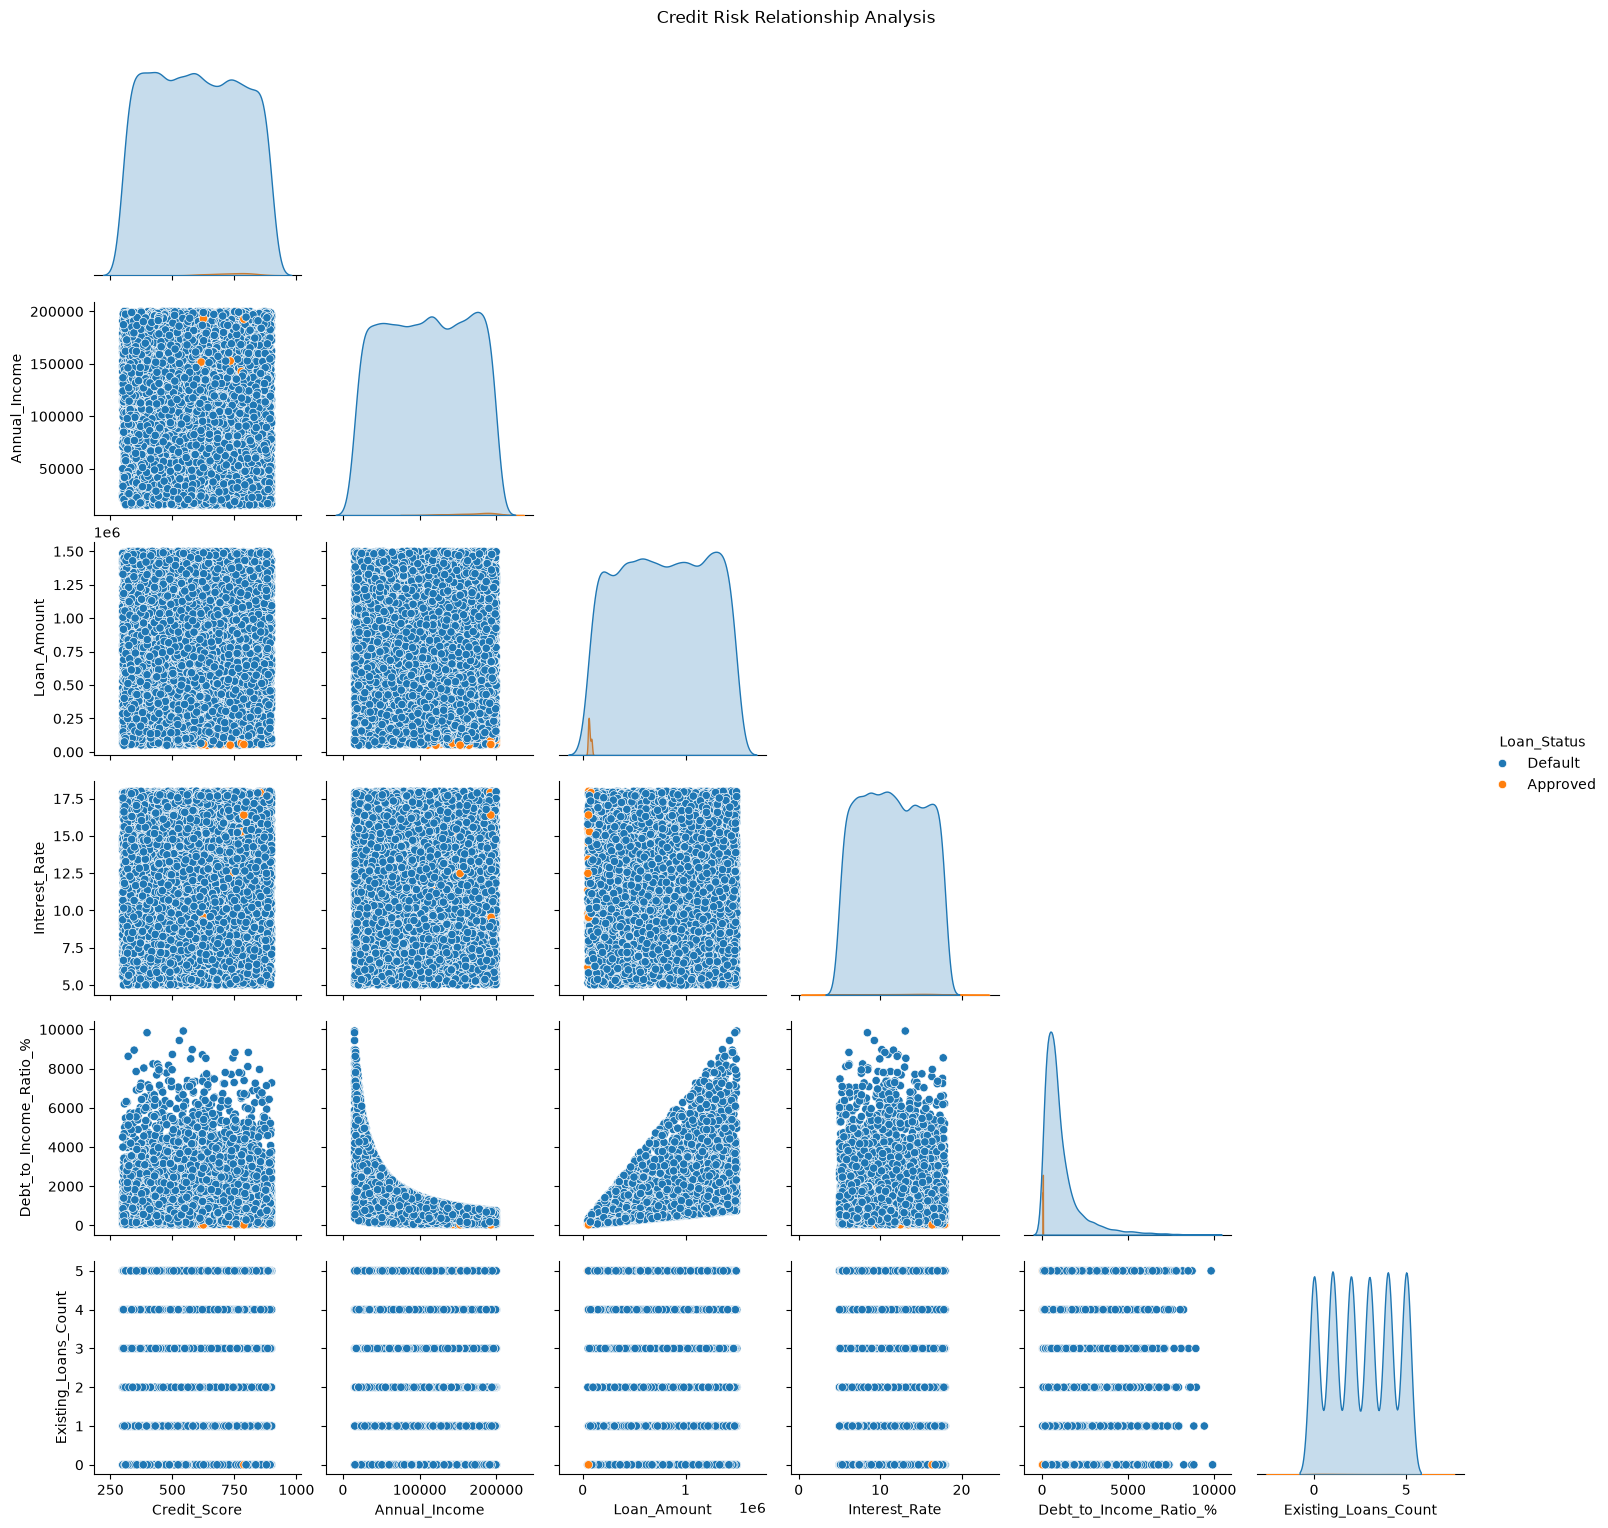

In [33]:
sns.pairplot(
    df[risk_columns + ["Loan_Status"]],
    hue="Loan_Status",
    corner=True
)

plt.suptitle("Credit Risk Relationship Analysis", y=1.02)

plt.show()

#### Pair Plot Risk Analysis:

#### The pair plot shows relationships among the key financial variables while distinguishing observations by Loan_Status.
#### The strongest visible relationships are:
#### - Annual Income and DTI show a negative relationship.
#### - Loan Amount and DTI show a positive relationship.
#### - Annual Income and Loan Amount show little apparent relationship.
#### Due to the highly imbalanced Loan_Status classes, the Approved observations are difficult to distinguish visually in the pair plot.